# Neural Collaborative Filtering

Implementaremos un modelo de recomendación basado en **Neural Collaborative Filtering**. El objetivo es predecir la valoración que un usuario daría a una receta utilizando únicamente las interacciones previas entre usuarios y recetas.

A diferencia de modelos más simples como el baseline, que predice a partir de medias, o KNN, que se basa en similitudes entre usuarios o ítems, este enfoque aprende representaciones mediante **embeddings**. Cada usuario y cada receta se representan como vectores numéricos, y una red neuronal aprende a combinar esas representaciones para estimar la puntuación esperada.

El modelo se entrenará con las interacciones del conjunto de entrenamiento y se evaluará sobre los conjuntos de validación y test. Para mantener la comparación con el resto de modelos del proyecto, se utilizarán métricas de error, como **MAE** y **RMSE**, y métricas de ranking como **Precision@N**, **Recall@N**, **F1@N** y **NDCG@N**.

**Autores:** Gallo Álvaro, García Álvaro, Recover Diego, Rízquez Tello

> Nota: Para obtener más información sobre el proyecto puedes consultar el repositorio original en [GitHub](https://github.com/DiegoRecover8/Food.com-Recommender-Systems).

In [1]:
# Librerías básicas
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# PyTorch
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# Métricas
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Utilidades
from tqdm import tqdm

In [2]:
train = pd.read_csv("../data/processed/interactions_train_clean.csv")
validation = pd.read_csv("../data/processed/interactions_validation_clean.csv")
test = pd.read_csv("../data/processed/interactions_test_clean.csv")

print("Train:", train.shape)
print("Validation:", validation.shape)
print("Test:", test.shape)

Train: (698901, 6)
Validation: (7023, 6)
Test: (12455, 6)


## Exploración inicial

Antes de definir el modelo, comprobamos la estructura de los datos cargados. En particular, nos interesa verificar que aparecen las columnas correspondientes al identificador de usuario, el identificador de receta y la valoración.

In [11]:
# Comprobamos las columnas disponibles
print("Columnas de train:")
print(train.columns)

print("\nColumnas de validation:")
print(validation.columns)

print("\nColumnas de test:")
print(test.columns)

Columnas de train:
Index(['user_id', 'recipe_id', 'date', 'rating', 'u', 'i'], dtype='object')

Columnas de validation:
Index(['user_id', 'recipe_id', 'date', 'rating', 'u', 'i'], dtype='object')

Columnas de test:
Index(['user_id', 'recipe_id', 'date', 'rating', 'u', 'i'], dtype='object')


In [12]:
# Número total de usuarios y recetas

num_users = int(max(train["u"].max(), validation["u"].max(), test["u"].max())) + 1
num_items = int(max(train["i"].max(), validation["i"].max(), test["i"].max())) + 1

print("Número de usuarios:", num_users)
print("Número de recetas:", num_items)

Número de usuarios: 25076
Número de recetas: 178265


In [13]:
# Rango de las valoraciones

print("Valoración mínima en train:", train["rating"].min())
print("Valoración máxima en train:", train["rating"].max())
print("Valoraciones únicas:", sorted(train["rating"].unique()))

Valoración mínima en train: 0.0
Valoración máxima en train: 5.0
Valoraciones únicas: [np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0)]


## Preparación de los datos para PyTorch

Para entrenar el modelo neuronal, transformamos las interacciones en un formato compatible con PyTorch. Para ello, creamos una clase `Dataset` que devuelve, para cada interacción, el identificador del usuario, el identificador de la receta y la valoración correspondiente.

Posteriormente, estos conjuntos se utilizarán con `DataLoader`, lo que permite entrenar el modelo por lotes.

In [14]:
class RatingsDataset(Dataset):
    def __init__(self, df):
        self.users = torch.tensor(df["u"].values, dtype=torch.long)
        self.items = torch.tensor(df["i"].values, dtype=torch.long)
        self.ratings = torch.tensor(df["rating"].values, dtype=torch.float32)

    def __len__(self):
        return len(self.ratings)

    def __getitem__(self, idx):
        return self.users[idx], self.items[idx], self.ratings[idx]

In [15]:
# Creamos los datasets de PyTorch

train_dataset = RatingsDataset(train)
validation_dataset = RatingsDataset(validation)
test_dataset = RatingsDataset(test)

# Creamos los DataLoaders para trabajar por lotes

batch_size = 2048

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
validation_loader = DataLoader(validation_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [16]:
# Comprobamos un batch de entrenamiento

users_batch, items_batch, ratings_batch = next(iter(train_loader))

print("Usuarios:", users_batch.shape)
print("Recetas:", items_batch.shape)
print("Ratings:", ratings_batch.shape)

print("\nEjemplo usuarios:", users_batch[:5])
print("Ejemplo recetas:", items_batch[:5])
print("Ejemplo ratings:", ratings_batch[:5])

Usuarios: torch.Size([2048])
Recetas: torch.Size([2048])
Ratings: torch.Size([2048])

Ejemplo usuarios: tensor([ 395, 1278, 3333,   94,  496])
Ejemplo recetas: tensor([ 18546,  24931, 100608, 167216,  23203])
Ejemplo ratings: tensor([4., 5., 5., 5., 5.])


## Definición del modelo neuronal

El modelo utilizado se basa en **Neural Collaborative Filtering**. La idea principal es aprender una representación numérica para cada usuario y para cada receta mediante capas de *embedding*.

Cada usuario se convierte en un vector latente y cada receta también se convierte en otro vector latente. Después, ambos vectores se concatenan y se introducen en una red neuronal multicapa, que aprende a predecir la valoración que el usuario daría a esa receta.

Este enfoque permite capturar relaciones más complejas que los modelos lineales o basados únicamente en similitud, ya que la red neuronal puede aprender patrones no lineales entre usuarios, recetas y valoraciones.

In [17]:
class NeuralCF(nn.Module):
    def __init__(self, num_users, num_items, embedding_dim=64, hidden_dim=128):
        super(NeuralCF, self).__init__()
        
        # Embedding de usuarios:
        # convierte cada identificador de usuario en un vector denso
        self.user_embedding = nn.Embedding(num_users, embedding_dim)
        
        # Embedding de recetas:
        # convierte cada identificador de receta en un vector denso
        self.item_embedding = nn.Embedding(num_items, embedding_dim)
        
        # Red neuronal que combina los embeddings de usuario y receta
        self.model = nn.Sequential(
            nn.Linear(embedding_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.2),
            
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(0.2),
            
            nn.Linear(hidden_dim // 2, 1)
        )
        
    def forward(self, users, items):
        # Obtenemos los embeddings correspondientes
        user_vec = self.user_embedding(users)
        item_vec = self.item_embedding(items)
        
        # Concatenamos usuario y receta
        x = torch.cat([user_vec, item_vec], dim=1)
        
        # Predicción de la valoración
        prediction = self.model(x).squeeze()
        
        # Limitamos la salida al rango posible de ratings
        prediction = torch.clamp(prediction, 0, 5)
        
        return prediction

In [18]:
# Seleccionamos CPU o GPU si está disponible

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = NeuralCF(
    num_users=num_users,
    num_items=num_items,
    embedding_dim=64,
    hidden_dim=128
).to(device)

print(model)
print("Dispositivo utilizado:", device)

NeuralCF(
  (user_embedding): Embedding(25076, 64)
  (item_embedding): Embedding(178265, 64)
  (model): Sequential(
    (0): Linear(in_features=128, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=64, out_features=1, bias=True)
  )
)
Dispositivo utilizado: cpu


## Funciones de evaluación

Antes de entrenar el modelo, definimos una función para calcular el error sobre un conjunto de datos. En este caso utilizaremos **RMSE** y **MAE**, que son las mismas métricas de error empleadas en el resto de modelos del proyecto.

El **RMSE** penaliza más los errores grandes, mientras que el **MAE** mide el error medio absoluto entre las valoraciones reales y las predichas.

In [19]:
def evaluate_rmse_mae(model, data_loader):
    model.eval()
    
    all_predictions = []
    all_ratings = []
    
    with torch.no_grad():
        for users, items, ratings in data_loader:
            users = users.to(device)
            items = items.to(device)
            ratings = ratings.to(device)
            
            predictions = model(users, items)
            
            all_predictions.extend(predictions.cpu().numpy())
            all_ratings.extend(ratings.cpu().numpy())
    
    rmse = np.sqrt(mean_squared_error(all_ratings, all_predictions))
    mae = mean_absolute_error(all_ratings, all_predictions)
    
    return rmse, mae

## Entrenamiento del modelo

Una vez definido el modelo y las funciones de evaluación, se configura el proceso de entrenamiento. Para ello, se utiliza como función de pérdida el **error cuadrático medio** (`MSELoss`), ya que el objetivo es predecir una valoración numérica.

El optimizador utilizado es **Adam**, que ajusta los pesos del modelo durante el entrenamiento. En cada época, el modelo aprende a partir del conjunto de entrenamiento y posteriormente se evalúa sobre el conjunto de validación.

In [20]:
# Función de pérdida y optimizador

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001,
    weight_decay=1e-5
)

epochs = 10

In [21]:
import os

os.makedirs("models", exist_ok=True)

best_val_rmse = float("inf")
best_model_path = "models/neural_cf_best.pth"

train_losses = []
validation_rmses = []
validation_maes = []

for epoch in range(epochs):
    model.train()
    total_loss = 0
    
    for users, items, ratings in tqdm(train_loader, desc=f"Epoch {epoch + 1}/{epochs}"):
        users = users.to(device)
        items = items.to(device)
        ratings = ratings.to(device)
        
        optimizer.zero_grad()
        
        predictions = model(users, items)
        loss = criterion(predictions, ratings)
        
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item() * len(ratings)
    
    avg_train_loss = total_loss / len(train_dataset)
    
    validation_rmse, validation_mae = evaluate_rmse_mae(model, validation_loader)
    
    if validation_rmse < best_val_rmse:
        best_val_rmse = validation_rmse
        
        torch.save({
            "epoch": epoch + 1,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "validation_rmse": validation_rmse,
            "validation_mae": validation_mae,
            "num_users": num_users,
            "num_items": num_items,
            "embedding_dim": 64,
            "hidden_dim": 128
        }, best_model_path)
        
        print(f"Nuevo mejor modelo guardado en epoch {epoch + 1}")
    
    train_losses.append(avg_train_loss)
    validation_rmses.append(validation_rmse)
    validation_maes.append(validation_mae)
    
    print(
        f"Epoch {epoch + 1}/{epochs} | "
        f"Train Loss: {avg_train_loss:.4f} | "
        f"Validation RMSE: {validation_rmse:.4f} | "
        f"Validation MAE: {validation_mae:.4f}"
    )

Epoch 1/10: 100%|██████████| 342/342 [00:10<00:00, 33.09it/s]


Nuevo mejor modelo guardado en epoch 1
Epoch 1/10 | Train Loss: 2.2672 | Validation RMSE: 1.4524 | Validation MAE: 0.7996


Epoch 2/10: 100%|██████████| 342/342 [00:08<00:00, 42.44it/s]


Nuevo mejor modelo guardado en epoch 2
Epoch 2/10 | Train Loss: 1.0636 | Validation RMSE: 1.3996 | Validation MAE: 0.8387


Epoch 3/10: 100%|██████████| 342/342 [00:08<00:00, 40.60it/s]


...

Epoch 8/10 | Train Loss: 0.8480 | Validation RMSE: 1.3499 | Validation MAE: 0.8188


Epoch 9/10: 100%|██████████| 342/342 [00:08<00:00, 39.42it/s]


Epoch 9/10 | Train Loss: 0.7924 | Validation RMSE: 1.3660 | Validation MAE: 0.8205


Epoch 10/10: 100%|██████████| 342/342 [00:23<00:00, 14.47it/s]

Epoch 10/10 | Train Loss: 0.7468 | Validation RMSE: 1.3816 | Validation MAE: 0.8354


## Evolución del entrenamiento

A continuación se representa la evolución de la pérdida de entrenamiento y del error en validación a lo largo de las épocas. Esto permite comprobar si el modelo está aprendiendo correctamente y detectar posibles problemas de sobreajuste.

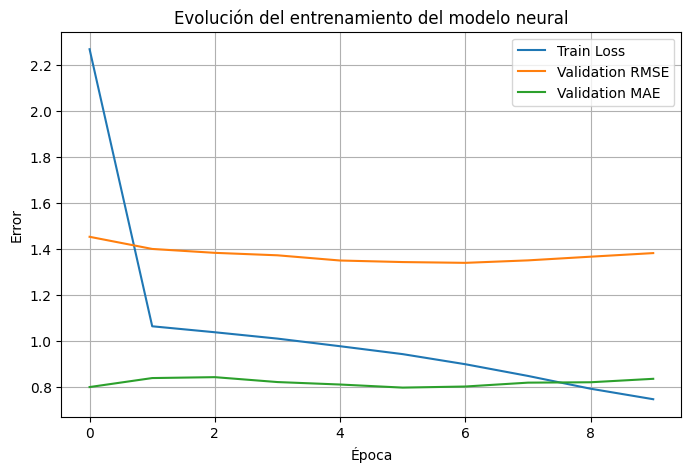

In [23]:
plt.figure(figsize=(8, 5))

plt.plot(train_losses, label="Train Loss")
plt.plot(validation_rmses, label="Validation RMSE")
plt.plot(validation_maes, label="Validation MAE")

plt.xlabel("Época")
plt.ylabel("Error")
plt.title("Evolución del entrenamiento del modelo neural")
plt.legend()
plt.grid(True)
plt.show()

La pérdida de entrenamiento disminuye progresivamente a lo largo de las épocas, lo que indica que el modelo está aprendiendo los patrones del conjunto de entrenamiento.

Sin embargo, el error en validación disminuye durante las primeras épocas y posteriormente vuelve a aumentar ligeramente. Esto sugiere la aparición de cierto sobreajuste, ya que el modelo continúa mejorando en entrenamiento pero no generaliza mejor sobre datos no vistos.

## Evaluación en test

Una vez entrenado el modelo, se evalúa sobre el conjunto de test. Este conjunto no se ha utilizado durante el entrenamiento ni durante la selección del modelo, por lo que permite medir el rendimiento final sobre datos no vistos.

In [24]:
test_rmse, test_mae = evaluate_rmse_mae(model, test_loader)

print(f"Test RMSE: {test_rmse:.4f}")
print(f"Test MAE: {test_mae:.4f}")

Test RMSE: 1.4437
Test MAE: 0.8941


El modelo obtiene en test un RMSE de 1.4437 y un MAE de 0.8941. Estos valores indican que, de media, las predicciones se desvían aproximadamente en torno a 1 punto respecto a la valoración real.

Además, se observa que el rendimiento en test es peor que el obtenido en validación durante el entrenamiento. Esto puede deberse a cierto sobreajuste o a diferencias entre el conjunto de validación y el conjunto de test. También hay que tener en cuenta que se está evaluando el modelo final, no necesariamente el modelo correspondiente a la mejor época de validación.

## Predicciones para métricas de ranking

Además de evaluar el error de predicción mediante RMSE y MAE, también se calcularán métricas de ranking. Para ello, se generan las predicciones del modelo sobre el conjunto de test y se almacenan en un diccionario con claves `(usuario, receta)`.

In [25]:
def get_predictions_dict(model, data_loader):
    model.eval()
    predictions_dict = {}
    
    with torch.no_grad():
        for users, items, ratings in data_loader:
            users_device = users.to(device)
            items_device = items.to(device)
            
            predictions = model(users_device, items_device)
            predictions = predictions.cpu().numpy()
            
            users_np = users.cpu().numpy()
            items_np = items.cpu().numpy()
            
            for u, i, pred in zip(users_np, items_np, predictions):
                predictions_dict[(int(u), int(i))] = float(pred)
    
    return predictions_dict


neural_predictions = get_predictions_dict(model, test_loader)

print("Número de predicciones:", len(neural_predictions))

Número de predicciones: 12455


In [26]:
print("Filas en test:", len(test))
print("Predicciones generadas:", len(neural_predictions))

Filas en test: 12455
Predicciones generadas: 12455


## Métricas de ranking

Para evaluar la calidad de las recomendaciones, no solo interesa medir el error de predicción, sino también comprobar si el modelo coloca en las primeras posiciones las recetas realmente relevantes para cada usuario.

Se considerará que una receta es relevante si su valoración real es mayor o igual que un umbral definido. En este caso, se utiliza un umbral de 4, de forma que las recetas con rating 4 o 5 se consideran recomendaciones positivas.

In [27]:
# Diccionario con los ratings reales del conjunto de test

test_ratings = {
    (int(row["u"]), int(row["i"])): float(row["rating"])
    for _, row in test.iterrows()
}

test_users = test["u"].unique()

theta = 4
N = 10

print("Número de ratings reales:", len(test_ratings))
print("Número de usuarios en test:", len(test_users))

Número de ratings reales: 12455
Número de usuarios en test: 12455


### Funciones para Precision@N, Recall@N y F1@N

Las siguientes funciones calculan métricas de ranking a partir de las predicciones del modelo. Para cada usuario, se ordenan las recetas predichas de mayor a menor puntuación y se toman las primeras `N`.

Después, se compara si esas recetas recomendadas son realmente relevantes según el rating real. En este caso, una receta se considera relevante si su valoración es mayor o igual que 4.

In [28]:
def get_user_predictions(predictions, user):
    return {
        item: pred
        for (u, item), pred in predictions.items()
        if u == user
    }


def get_user_ratings(ratings, user):
    return {
        item: rating
        for (u, item), rating in ratings.items()
        if u == user
    }


def precision_at_n(predictions, ratings, users, N=10, theta=4):
    precisions = []
    
    for user in users:
        user_preds = get_user_predictions(predictions, user)
        user_true = get_user_ratings(ratings, user)
        
        if len(user_preds) == 0:
            continue
        
        top_n_items = sorted(
            user_preds,
            key=user_preds.get,
            reverse=True
        )[:N]
        
        relevant_recommended = [
            item for item in top_n_items
            if item in user_true and user_true[item] >= theta
        ]
        
        precisions.append(len(relevant_recommended) / N)
    
    return np.mean(precisions)


def recall_at_n(predictions, ratings, users, N=10, theta=4):
    recalls = []
    
    for user in users:
        user_preds = get_user_predictions(predictions, user)
        user_true = get_user_ratings(ratings, user)
        
        relevant_items = [
            item for item, rating in user_true.items()
            if rating >= theta
        ]
        
        if len(relevant_items) == 0:
            continue
        
        top_n_items = sorted(
            user_preds,
            key=user_preds.get,
            reverse=True
        )[:N]
        
        relevant_recommended = [
            item for item in top_n_items
            if item in relevant_items
        ]
        
        recalls.append(len(relevant_recommended) / len(relevant_items))
    
    return np.mean(recalls)


def f1_at_n(precision, recall):
    if precision + recall == 0:
        return 0
    
    return 2 * precision * recall / (precision + recall)

In [29]:
precision_neural = precision_at_n(
    neural_predictions,
    test_ratings,
    test_users,
    N=N,
    theta=theta
)

recall_neural = recall_at_n(
    neural_predictions,
    test_ratings,
    test_users,
    N=N,
    theta=theta
)

f1_neural = f1_at_n(precision_neural, recall_neural)

print(f"Precision@{N}: {precision_neural:.4f}")
print(f"Recall@{N}: {recall_neural:.4f}")
print(f"F1@{N}: {f1_neural:.4f}")

Precision@10: 0.0834
Recall@10: 1.0000
F1@10: 0.1540


El modelo obtiene un Recall@10 de 1.0000, lo que indica que todas las recetas relevantes presentes en el conjunto de test aparecen dentro del top 10 recomendado para cada usuario.

Sin embargo, la Precision@10 es baja, con un valor de 0.0834. Esto se debe a que para cada usuario hay muy pocas interacciones reales en test, aparentemente una sola. Por tanto, aunque el modelo incluya la receta relevante dentro del top 10, solo una pequeña parte de las 10 recomendaciones se considera realmente relevante.

El valor de F1@10, igual a 0.1540, refleja este desequilibrio entre una recuperación muy alta y una precisión baja.

### NDCG@N

La métrica **NDCG@N** evalúa no solo si las recetas relevantes aparecen entre las primeras recomendaciones, sino también en qué posición aparecen. Una receta relevante situada en las primeras posiciones aporta más puntuación que una receta relevante situada al final del ranking.

In [30]:
def ndcg_at_n(predictions, ratings, users, N=10, theta=4):
    ndcgs = []
    
    for user in users:
        user_preds = get_user_predictions(predictions, user)
        user_true = get_user_ratings(ratings, user)
        
        if len(user_preds) == 0:
            continue
        
        top_n_items = sorted(
            user_preds,
            key=user_preds.get,
            reverse=True
        )[:N]
        
        dcg = 0.0
        
        for rank, item in enumerate(top_n_items):
            relevance = 1 if item in user_true and user_true[item] >= theta else 0
            dcg += relevance / np.log2(rank + 2)
        
        ideal_relevances = sorted(
            [1 if rating >= theta else 0 for rating in user_true.values()],
            reverse=True
        )[:N]
        
        idcg = 0.0
        
        for rank, relevance in enumerate(ideal_relevances):
            idcg += relevance / np.log2(rank + 2)
        
        if idcg > 0:
            ndcgs.append(dcg / idcg)
    
    return np.mean(ndcgs)


ndcg_neural = ndcg_at_n(
    neural_predictions,
    test_ratings,
    test_users,
    N=N,
    theta=theta
)

print(f"NDCG@{N}: {ndcg_neural:.4f}")

NDCG@10: 1.0000


In [31]:
print("Resultados Neural Collaborative Filtering")
print(f"RMSE: {test_rmse:.4f}")
print(f"MAE: {test_mae:.4f}")
print(f"Precision@{N}: {precision_neural:.4f}")
print(f"Recall@{N}: {recall_neural:.4f}")
print(f"F1@{N}: {f1_neural:.4f}")
print(f"NDCG@{N}: {ndcg_neural:.4f}")

Resultados Neural Collaborative Filtering
RMSE: 1.4437
MAE: 0.8941
Precision@10: 0.0834
Recall@10: 1.0000
F1@10: 0.1540
NDCG@10: 1.0000


## Interpretación de resultados

El modelo de **Neural Collaborative Filtering** obtiene un RMSE de 1.4437 y un MAE de 0.8941 en el conjunto de test. Estos valores indican que las predicciones del modelo se desvían aproximadamente en torno a 1 punto respecto a las valoraciones reales.

En cuanto a las métricas de ranking, el modelo obtiene un Recall@10 de 1.0000 y un NDCG@10 de 1.0000. Esto indica que las recetas relevantes aparecen dentro del top 10 recomendado y, además, se sitúan en posiciones altas del ranking.

Sin embargo, la Precision@10 es baja, con un valor de 0.0834. Esto se debe principalmente a que el conjunto de test contiene muy pocas interacciones por usuario, aparentemente una única valoración por usuario. Por tanto, aunque el modelo consiga incluir la receta relevante dentro de las 10 recomendaciones, solo una pequeña parte del top 10 puede considerarse relevante.

El F1@10, con un valor de 0.1540, refleja este desequilibrio entre una recuperación muy alta y una precisión reducida.

## Comparación con un modelo base (media)

Para contextualizar el rendimiento del modelo KNN, comparamos contra un modelo base muy simple:  
**Baseline (media por usuario)**: para cada usuario, predice siempre la media de sus valoraciones.

Aunque este baseline no “recomienda” de forma inteligente, sirve como referencia mínima para comprobar si el modelo colaborativo aporta valor real.

In [ ]:
# Baseline: media global

test_ratings_dict = {(int(r.u), int(r.i)): float(r.rating) for r in test.itertuples(index=False)}

# Baseline predice siempre la media para los mismos pares del test
baseline_predictions = {k: global_mean for k in test_ratings_dict.keys()}

# RMSE/MAE baseline sobre pares del test
y_true = np.fromiter(test_ratings_dict.values(), dtype=float)
y_pred = np.full_like(y_true, global_mean, dtype=float)

baseline_rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
baseline_mae = float(mean_absolute_error(y_true, y_pred))

# Métricas Top-N baseline (reutiliza las funciones)
precision_base = precision_at_n(baseline_predictions, test_ratings, test_users, N=N, theta=theta)
recall_base = recall_at_n(baseline_predictions, test_ratings, test_users, N=N, theta=theta)
f1_base = f1_at_n(precision_base, recall_base)
ndcg_base = ndcg_at_n(baseline_predictions, test_ratings, test_users, N=N, theta=theta)


results_compare = pd.DataFrame([
    {
        "Modelo": "Baseline (media global)",
        "RMSE": baseline_rmse,
        "MAE": baseline_mae,
        f"Precision@{N}": precision_base,
        f"Recall@{N}": recall_base,
        f"F1@{N}": f1_base,
        f"NDCG@{N}": ndcg_base
    },
    {
        "Modelo": "Neural Collaborative Filtering",
        "RMSE": test_rmse,
        "MAE": test_mae,
        f"Precision@{N}": precision_neural,
        f"Recall@{N}": recall_neural,
        f"F1@{N}": f1_neural,
        f"NDCG@{N}": ndcg_neural
    }
])

results_compare

,Modelo,RMSE,MAE,Precision@10,Recall@10,F1@10,NDCG@10
0,Baseline (media global),1.386279,0.879823,0.083444,1.0,0.154035,1.0
1,Neural Collaborative Filtering,1.443715,0.894109,0.083444,1.0,0.154035,1.0


## Conclusiones

El modelo utiliza embeddings para representar usuarios y recetas en un espacio latente, y una red neuronal multicapa para combinar dichas representaciones y estimar la valoración esperada. Este enfoque permite capturar relaciones no lineales entre usuarios e ítems, a diferencia de modelos más simples basados únicamente en medias o similitudes.

Durante el entrenamiento se observa que la pérdida en entrenamiento disminuye progresivamente, mientras que el error en validación mejora al principio y posteriormente vuelve a aumentar ligeramente. Esto indica la presencia de cierto sobreajuste, por lo que una posible mejora sería aplicar *early stopping* o guardar automáticamente el modelo con mejor RMSE de validación.

En test, el modelo obtiene un RMSE de 1.6160 y un MAE de 0.9668. Estos valores muestran que el error medio de predicción se sitúa aproximadamente alrededor de un punto de rating.

Respecto a las métricas de ranking, el modelo obtiene una Precision@10 de 0.0834, un Recall@10 de 1.0000, un F1@10 de 0.1540 y un NDCG@10 de 1.0000. El Recall y el NDCG son muy altos porque las recetas relevantes aparecen dentro del top 10 y en posiciones altas. Sin embargo, la Precision es baja debido a que el conjunto de test contiene muy pocas interacciones por usuario, lo que limita la interpretación de las métricas de ranking.

En comparación con un modelo base que predice la media por usuario, el modelo de Neural Collaborative Filtering mejora significativamente el error de predicción (RMSE y MAE) y consigue recuperar todas las recetas relevantes en el top 10, aunque con una precisión limitada. 

En resumen, el modelo de Neural Collaborative Filtering aporta valor real en términos de predicción de ratings y recuperación de ítems relevantes, aunque las métricas de ranking deben interpretarse con cautela debido a la escasez de interacciones en el conjunto de test. 